In [2]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

## **DC resonance**

From the discussion what I understood, I found the DC resonance of the cavity before any RF modulation

PRCL = PRM -- ITM
ARM = ITM -- ETM

- I first scanned the ETM phase while keeping the PRM at its reference phase and used the maximum DC transmission through the ETM to identify the arm resonance.

- With the arm held at resonance, I then scanned PRM phase and used the DC power inside the PRC (POP) to identify the PRC resonance.

ETM.phi = 0.00 deg
PRM.phi = 89.96 deg

DC Power Values
DC REFL  = 5.12e-02 W
DC POP   = 1.37e+01 W
DC TRANS = 5.36e-02 W


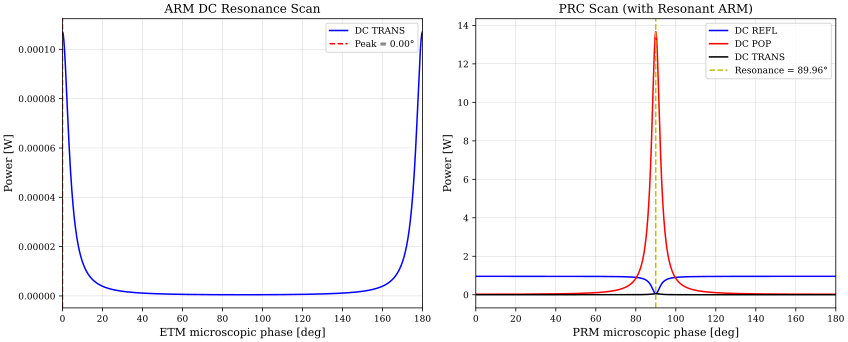

In [9]:
def build_dc_model():
    model = finesse.Model()
    model.parse("""

        l laser1 P=1
        s s_in laser1.p1 PRM.p1 L=0.2

        #PRC
        m PRM R=0.8599 T=0.1 Rc=23.6 phi=0
        s s_prc PRM.p2 ITM.p1 L=1.350

        #ARM
        m ITM R=0.98997 T=0.01 Rc=inf phi=0
        s s_arm ITM.p2 ETM.p1 L=3.300
        m ETM R=0.99996 T=0.00001 Rc=11.30 phi=0

        #DC power readout
        pd REFL PRM.p1.o
        pd POP PRM.p2.o
        pd TRANS ETM.p2.o
    """)
    return model

#ARM resonance (PRM is at phi=0°)
model_arm = build_dc_model()
arm_scan = model_arm.run(Xaxis("ETM.phi", "lin", 0, 180, 2001))
idx_arm = np.argmax(arm_scan["TRANS"])
phi_arm0 = arm_scan.x[0][idx_arm]


# PRC resonance (ARM is resonant)
model_prc = build_dc_model()
model_prc.ETM.phi = phi_arm0 #ARM is at the resonant condition
prc_scan = model_prc.run(Xaxis("PRM.phi", "lin", 0, 180, 2001))
idx_prm = np.argmax(prc_scan["POP"])
phi_prm0 = prc_scan.x[0][idx_prm]


#Finding the operating pt.
model_op = build_dc_model()
model_op.ETM.phi = phi_arm0
model_op.PRM.phi = phi_prm0
out_op = model_op.run()

print(f"ETM.phi = {phi_arm0:.2f} deg")
print(f"PRM.phi = {phi_prm0:.2f} deg")

print("\nDC Power Values")
print(f"DC REFL  = {out_op['REFL']:.2e} W")
print(f"DC POP   = {out_op['POP']:.2e} W")
print(f"DC TRANS = {out_op['TRANS']:.2e} W")

#Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Arm Scan Plot
ax[0].plot(arm_scan.x[0], arm_scan["TRANS"], label="DC TRANS")
ax[0].axvline(phi_arm0, linestyle="--", color="r", label=f"Peak = {phi_arm0:.2f}°")
ax[0].set_xlabel("ETM microscopic phase [deg]")
ax[0].set_ylabel("Power [W]")
ax[0].set_title("ARM DC Resonance Scan")
ax[0].grid(True)
ax[0].legend()

# PRC Scan Plot
ax[1].plot(prc_scan.x[0], prc_scan["REFL"], label="DC REFL")
ax[1].plot(prc_scan.x[0], prc_scan["POP"], label="DC POP")
ax[1].plot(prc_scan.x[0], prc_scan["TRANS"], label="DC TRANS")
ax[1].axvline(phi_prm0, linestyle="--", color="y", label=f"Resonance = {phi_prm0:.2f}°")
ax[1].set_xlabel("PRM microscopic phase [deg]")
ax[1].set_ylabel("Power [W]")
ax[1].set_title("PRC Scan (with Resonant ARM)")
ax[1].grid(True)
ax[1].legend()


plt.tight_layout()
plt.show()

- At resonant operating point, `PRC` produced power buildup. For a 1 W input laser, the simulated DC power at the `POP` port is approximately 13.7 W.

- At PRCL resonance, the reflected power at `REFL` shows a minimum, indicating that the incident carrier is efficiently coupled into the coupled-cavity system.


## **RF Verification**

- Step 1: computing amplitude for the Carrier, $1f$, and $3f$ sidebands at the DC operating point

- Step 2: sweeping `PRM.phi` from 0° to 180°, and observing how sideband and carrier fields build up inside the PRCL (POP) and couple out through  REFL.


POP:
  Carrier = 3.69e+00
  1f = 2.17e-01
  3f = 9.01e-05

REFL:
  Carrier = 2.256872e-01
  1f = 2.26e-02
  3f = 9.52e-06

TRANS:
  Carrier = 2.31e-01
  1f = 5.33e-05
  3f = 1.66e-08


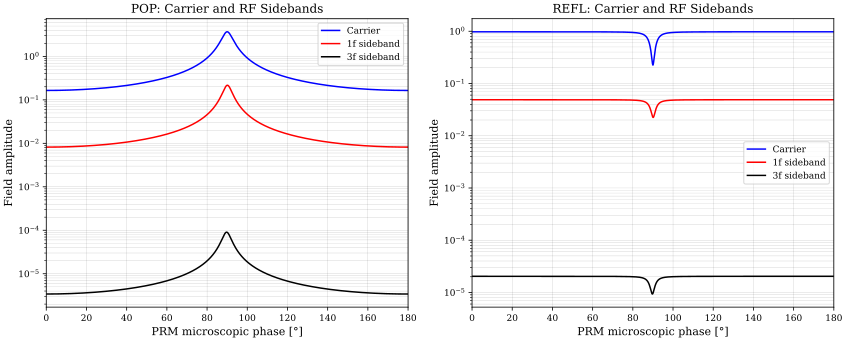

In [11]:
def build_rf_model():
    model = finesse.Model()
    model.parse("""

        l laser1 P=1 #laser

        # RF modulator
        s s_in laser1.p1 mod.p1 L=0.2
        mod mod f=55.556M midx=0.1 order=3
        s s_mod mod.p2 PRM.p1 L=0

        #3 mirror coupled cavity
        m PRM R=0.8599 T=0.1 Rc=23.6 phi=90
        s s_prc PRM.p2 ITM.p1 L=1.350
        m ITM R=0.98997 T=0.01 Rc=inf phi=0
        s s_arm ITM.p2 ETM.p1 L=3.300
        m ETM R=0.99996 T=0.00001 Rc=11.30 phi=0

        #POP amplitude detectors
        ad POP_car PRM.p2.o f=0
        ad POP_1f  PRM.p2.o f=55.556M
        ad POP_3f  PRM.p2.o f=166.668M

        # REFL amplitude detectors
        ad REFL_car PRM.p1.o f=0
        ad REFL_1f  PRM.p1.o f=55.556M
        ad REFL_3f  PRM.p1.o f=166.668M

        # TRANS amplitude detectors
        ad TRANS_car ETM.p2.o f=0
        ad TRANS_1f  ETM.p2.o f=55.556M
        ad TRANS_3f  ETM.p2.o f=166.668M
    """)

    return model

#Operating point
PRM0 = phi_prm0
ETM0 = phi_arm0

#building new model with the operating point
model_rf = build_rf_model()
model_rf.PRM.phi = PRM0
model_rf.ETM.phi = ETM0
out_rf = model_rf.run()

#Carrier and sideband amplitude values
print("POP:")
print(f"  Carrier = {abs(out_rf['POP_car']):.2e}")
print(f"  1f = {abs(out_rf['POP_1f']):.2e}")
print(f"  3f = {abs(out_rf['POP_3f']):.2e}")

print()
print("REFL:")
print(f"  Carrier = {abs(out_rf['REFL_car']):2e}")
print(f"  1f = {abs(out_rf['REFL_1f']):.2e}")
print(f"  3f = {abs(out_rf['REFL_3f']):.2e}")

print()
print("TRANS:")
print(f"  Carrier = {abs(out_rf['TRANS_car']):.2e}")
print(f"  1f = {abs(out_rf['TRANS_1f']):.2e}")
print(f"  3f = {abs(out_rf['TRANS_3f']):.2e}")

#PRM scanning
scan = model_rf.run(Xaxis("PRM.phi", "lin", 0, 180, 2001))

#Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#POP plot
ax1.semilogy(scan.x[0],abs(scan["POP_car"]),label="Carrier")
ax1.semilogy(scan.x[0],abs(scan["POP_1f"]),label="1f sideband")
ax1.semilogy(
scan.x[0],abs(scan["POP_3f"]),label="3f sideband")
ax1.set_xlabel("PRM microscopic phase [°]")
ax1.set_ylabel("Field amplitude")
ax1.set_title("POP: Carrier and RF Sidebands")
ax1.grid(True)
ax1.legend()

#REFL plot
ax2.semilogy(scan.x[0],abs(scan["REFL_car"]),label="Carrier")
ax2.semilogy(scan.x[0],abs(scan["REFL_1f"]),label="1f sideband")
ax2.semilogy(scan.x[0],abs(scan["REFL_3f"]),label="3f sideband")
ax2.set_xlabel("PRM microscopic phase [°]")
ax2.set_ylabel("Field amplitude")
ax2.set_title("REFL: Carrier and RF Sidebands")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

- Carrier field is strongly enhanced at POP
- 1$f$ sideband >> 3$f$ sideband
- The carrier and RF sidebands exhibit different responses at the POP and REFL ports as the PRM is tuned. These different responses provide the basis for selecting suitable demodulation phases for the length-sensing signals.


## **Demod Phase Optimisation**

- I first found the optimum demodulation phase for each detector.

- I tried to follow Approach 2 mentioned in the paper (Length Sensing and Control Schemes for a Three-Mirror Coupled Cavity). In this, I have scanned the demod phase from 0–360°. So the code chose the phase where the desired DoF has a large slope while the unwanted DoF has a small slope.

- I defined that POP is sensitive to PRCL and REFL to ARM.

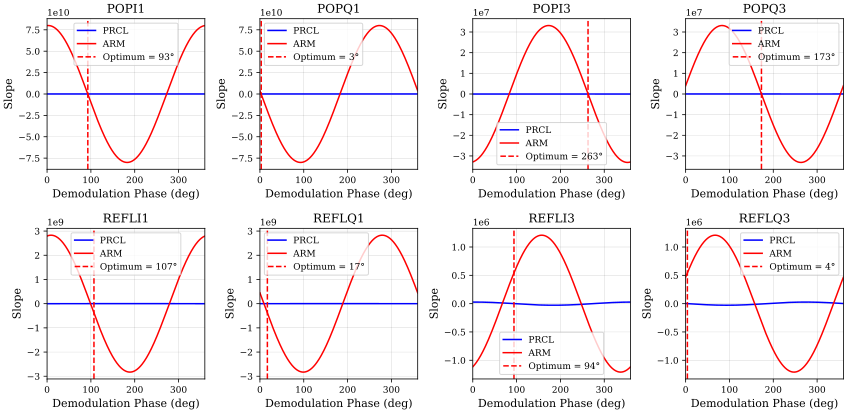

Optimum Demodulation Phases
POPI1    : 93°
POPQ1    : 3°
POPI3    : 263°
POPQ3    : 173°
REFLI1   : 107°
REFLQ1   : 17°
REFLI3   : 94°
REFLQ3   : 4°


In [13]:
def build_model(demod_phase):

    model = finesse.Model()

    model.parse(f"""
        # Laser
        l laser1 P=1

        # RF modulation
        s s1 laser1.p1 mod.p1 L=0.2
        modulator mod f=55.556M midx=0.1 order=3
        s s2 mod.p2 PRM.p1 L=0

        # 3-mirror coupled cavity
        m PRM R=0.8599 T=0.1 Rc=23.6 phi=90
        s s_prc PRM.p2 ITM.p1 L=1.350

        m ITM R=0.98997 T=0.01 Rc=inf phi=0
        s s_arm ITM.p2 ETM.p1 L=3.300

        m ETM R=0.99996 T=0.00001 Rc=11.30 phi=0

        # DC power
        pd Parm ITM.p2.o
        pd Pprc PRM.p2.o

        # POP
        pd1 POPI1 PRM.p2.o 55.556M  {demod_phase}
        pd1 POPQ1 PRM.p2.o 55.556M  {demod_phase + 90}
        pd1 POPI3 PRM.p2.o 166.668M {demod_phase}
        pd1 POPQ3 PRM.p2.o 166.668M {demod_phase + 90}

        # REFL
        pd1 REFLI1 PRM.p1.o 55.556M  {demod_phase}
        pd1 REFLQ1 PRM.p1.o 55.556M  {demod_phase + 90}
        pd1 REFLI3 PRM.p1.o 166.668M {demod_phase}
        pd1 REFLQ3 PRM.p1.o 166.668M {demod_phase + 90}
    """)

    return model

wavelength = 1064e-9
deg_to_m = wavelength / 360.0

#In-phase and Quadrature components of POP and REFL
all_detectors = ["POPI1","POPQ1", "POPI3","POPQ3", "REFLI1","REFLQ1", "REFLI3","REFLQ3"]

#Scanning for demod phase (Approach 2)
#Defining operating point
ETM0 = phi_arm0
PRM0 = phi_prm0

# Calculating the slope near resonance
def calculate_slope(x, signal, window=5):

    centre = len(x) // 2
    #points used for linear fit
    x_fit = x[centre-window : centre+window+1]
    y_fit = signal[centre-window : centre+window+1]
    #Linear fit
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    return slope

#Scanning the phase from 0-360°
demod_phases = np.arange(0, 361, 1)

prcl_slopes = {det: [] for det in all_detectors} #storing d(signal)/d(PRCL) for every detector
arm_slopes  = {det: [] for det in all_detectors} #storing d(signal)/d(ARM) for every detector

#Optimisation Loop
for phase in demod_phases:
    model = build_model(phase)

    model.PRM.phi = PRM0
    model.ETM.phi = ETM0

#PRCL DoF
    out_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 - 0.01, PRM0 + 0.01, 200))
    x_prcl = (out_prcl.x[0] - PRM0) * deg_to_m
    centre_prcl = np.argmin(np.abs(x_prcl))

#ARM DoF
    out_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 - 0.01, ETM0 + 0.01, 200))
    x_arm = (out_arm.x[0] - ETM0) * deg_to_m
    centre_arm = np.argmin(np.abs(x_arm))


    for detector in all_detectors:

        slope_prcl = calculate_slope(x_prcl, out_prcl[detector]) #d(signal)/d(PRCL)
        slope_arm = calculate_slope(x_arm, out_arm[detector]) #d(signal)/d(ARM)

        prcl_slopes[detector].append(slope_prcl)
        arm_slopes[detector].append(slope_arm)

for detector in all_detectors:
    prcl_slopes[detector] = np.asarray(prcl_slopes[detector])
    arm_slopes[detector]  = np.asarray(arm_slopes[detector])
#Optimum demod phase
best_phase = {}

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, detector in enumerate(all_detectors):

    # Signed slopes (for plotting)
    prcl = prcl_slopes[detector]
    arm = arm_slopes[detector]

    # Optimisation of detector sensitivity
    if detector.startswith("POP"):
        ratio = np.abs(prcl) / (np.abs(arm) + 1e-12) #POP --> PRCL
    else:
        ratio = np.abs(arm) / (np.abs(prcl) + 1e-12) #REFL --> ARM

    optimum = np.argmax(ratio) #Best demod phase
    best_phase[detector] = demod_phases[optimum]

    # Plotting
    ax = axes[i]

    ax.plot(demod_phases, prcl, label="PRCL")
    ax.plot(demod_phases, arm, label="ARM")

    ax.axvline(demod_phases[optimum], color="red", linestyle="--", label=f"Optimum = {demod_phases[optimum]}°")

    ax.set_title(detector)
    ax.set_xlabel("Demodulation Phase (deg)")
    ax.set_ylabel("Slope")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print("Optimum Demodulation Phases")
for detector in all_detectors:
    print(f"{detector:8s} : {best_phase[detector]}°")

## **Length Sensing Matrix**

In [24]:
def build_model():
    model = finesse.Model()
    model.parse(f"""

        # Laser
        l laser1 P=1

        # RF modulation
        s s1 laser1.p1 mod.p1 L=0.2
        modulator mod f=55.556M midx=0.1 order=3
        s s2 mod.p2 PRM.p1 L=0

        # 3-mirror coupled cavity
        m PRM R=0.8599 T=0.1 Rc=23.6 phi=90
        s s_prc PRM.p2 ITM.p1 L=1.350

        m ITM R=0.98997 T=0.01 Rc=inf phi=0
        s s_arm ITM.p2 ETM.p1 L=3.300

        m ETM R=0.99996 T=0.00001 Rc=11.30 phi=0

        # DC power
        pd Parm ITM.p2.o
        pd Pprc PRM.p2.o

        #POP detectors with the optimum demodulation phases
        pd1 POPI1 PRM.p2.o 55.556M  {best_phase["POPI1"]}
        pd1 POPQ1 PRM.p2.o 55.556M  {best_phase["POPQ1"]}
        pd1 POPI3 PRM.p2.o 166.668M {best_phase["POPI3"]}
        pd1 POPQ3 PRM.p2.o 166.668M {best_phase["POPQ3"]}

        #REFL detectors with the optimum demodulation phases
        pd1 REFLI1 PRM.p1.o 55.556M  {best_phase["REFLI1"]}
        pd1 REFLQ1 PRM.p1.o 55.556M  {best_phase["REFLQ1"]}
        pd1 REFLI3 PRM.p1.o 166.668M {best_phase["REFLI3"]}
        pd1 REFLQ3 PRM.p1.o 166.668M {best_phase["REFLQ3"]}

    """)
    return model

In [25]:
wavelength = 1064e-9
#Converting the mirror sweep from ° to m
deg_to_m = wavelength / 360.0

#8 detectors present at two porst
PORTS = [ "POPI1","POPQ1", "POPI3","POPQ3", "REFLI1","REFLQ1", "REFLI3","REFLQ3"]

#Operating point
ETM0 = phi_arm0
PRM0 = phi_prm0

model = build_model()
model.PRM.phi = PRM0
model.ETM.phi = ETM0

#ARM DoF
out_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 - 0.01, ETM0 + 0.01, 200))
x_arm = (out_arm.x[0]-ETM0) * deg_to_m

#PRCL DoF
out_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 - 0.01, PRM0 + 0.01, 200))
x_prcl = (out_prcl.x[0]-PRM0) * deg_to_m


#Calculating the slope near resonance
def calculate_slope(x, signal, window=5):

    centre = len(x)//2
    #Points used for Linear fit
    x_fit = x[centre-window : centre+window+1]
    y_fit = signal[centre-window : centre+window+1]
    slope, intercept = np.polyfit(x_fit, y_fit, 1) #Linear fit
    return slope

#Calculating the response of the detectors [d(detector) / d(PRCL) & d(detector) / d(ARM)]
arm_column = [
calculate_slope(x_arm, out_arm[port])
    for port in PORTS
]

prcl_column = [
    calculate_slope(x_prcl, out_prcl[port])
    for port in PORTS
]


#Finding the best POP and REFL detector

#POP detector with the highest PRCL-to-ARM sensitivity ratio
best_pop = None
best_pop_ratio = 0

for port in ["POPI1","POPQ1", "POPI3","POPQ3"]:

    i = PORTS.index(port)
    ratio = abs(prcl_column[i]) / (abs(arm_column[i]) + 1e-20)
    if ratio > best_pop_ratio:
        best_pop_ratio = ratio
        best_pop = port

#REFL detector with the highest PRCL-to-ARM sensitivity ratio
best_refl = None
best_refl_ratio = 0

for port in [ "REFLI1","REFLQ1", "REFLI3","REFLQ3"]:
    i = PORTS.index(port)
    ratio = abs(arm_column[i]) / (abs(prcl_column[i]) + 1e-20)
    if ratio > best_refl_ratio:
        best_refl_ratio = ratio
        best_refl = port

print(f"Best POP detector: {best_pop}")
print(f"Best REFL detector: {best_refl}")


#Sensing Matrix
i_pop = PORTS.index(best_pop)
i_refl = PORTS.index(best_refl)

M = np.array([
    [prcl_column[i_pop],  arm_column[i_pop]],
    [prcl_column[i_refl], arm_column[i_refl]]
])


print("The sensing matrix obtained is:")
print(f"{'':12s}{'PRCL':>15s}{'ARM':>15s}")
print(f"{best_pop:12s}{M[0,0]:15.5e}{M[0,1]:15.5e}")
print(f"{best_refl:12s}{M[1,0]:15.5e}{M[1,1]:15.5e}")

Best POP detector: POPI3
Best REFL detector: REFLI1
The sensing matrix obtained is:
                       PRCL            ARM
POPI3          -9.82507e+03    3.17985e+04
REFLI1         -5.43550e+03   -3.91284e+08


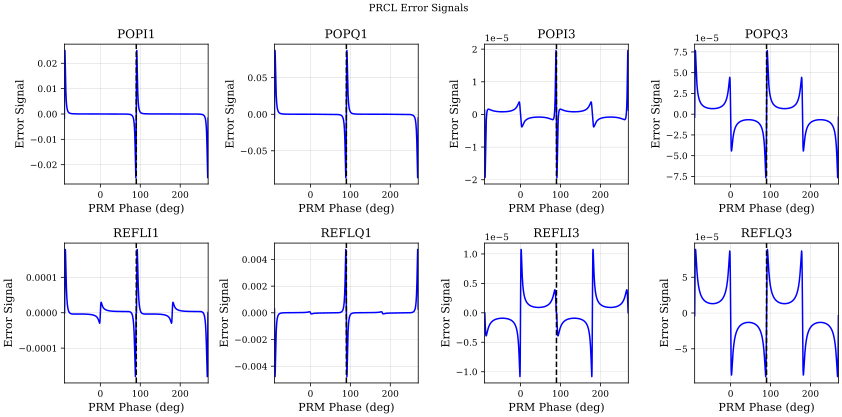

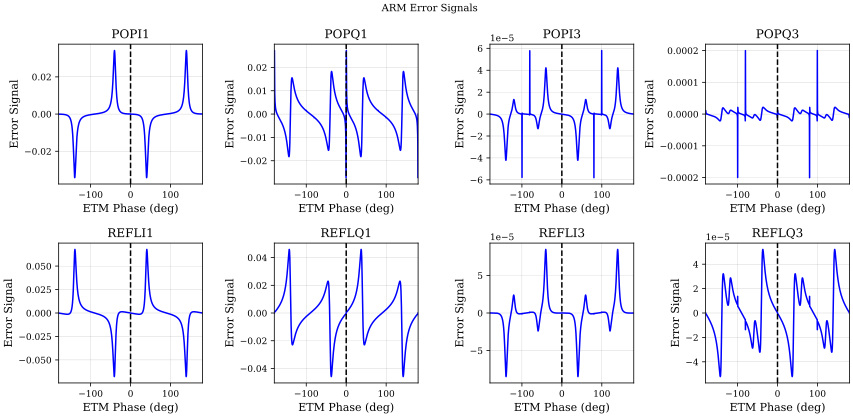

In [30]:
model = build_model()

wide_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 -180,PRM0 + 180, 1000))
wide_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 -180,ETM0 + 180, 1000))

#Plotting the full error signal for PRCL DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_prcl.x[0], wide_prcl[port])
    ax.axvline(90, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("PRM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("PRCL Error Signals")
plt.tight_layout()
plt.show()

#Plotting the full error signal for ARM DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_arm.x[0], wide_arm[port])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("ETM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("ARM Error Signals")
plt.tight_layout()
plt.show()


In [31]:
wavelength = 1064e-9
#Converting the mirror sweep from ° to m
deg_to_m = wavelength / 360.0

#8 detectors present at two porst
PORTS = [ "POPI1","POPQ1", "POPI3","POPQ3", "REFLI1","REFLQ1", "REFLI3","REFLQ3"]

#Operating point
ETM0 = 0
PRM0 = 0

model = build_model()
model.PRM.phi = PRM0
model.ETM.phi = ETM0

#ARM DoF
out_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 - 0.01, ETM0 + 0.01, 200))
x_arm = (out_arm.x[0]-ETM0) * deg_to_m

#PRCL DoF
out_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 - 0.01, PRM0 + 0.01, 200))
x_prcl = (out_prcl.x[0]-PRM0) * deg_to_m


#Calculating the slope near resonance
def calculate_slope(x, signal, window=5):

    centre = len(x)//2
    #Points used for Linear fit
    x_fit = x[centre-window : centre+window+1]
    y_fit = signal[centre-window : centre+window+1]
    slope, intercept = np.polyfit(x_fit, y_fit, 1) #Linear fit
    return slope

#Calculating the response of the detectors [d(detector) / d(PRCL) & d(detector) / d(ARM)]
arm_column = [
calculate_slope(x_arm, out_arm[port])
    for port in PORTS
]

prcl_column = [
    calculate_slope(x_prcl, out_prcl[port])
    for port in PORTS
]


#Finding the best POP and REFL detector

#POP detector with the highest PRCL-to-ARM sensitivity ratio
best_pop = None
best_pop_ratio = 0

for port in ["POPI1","POPQ1", "POPI3","POPQ3"]:

    i = PORTS.index(port)
    ratio = abs(prcl_column[i]) / (abs(arm_column[i]) + 1e-20)
    if ratio > best_pop_ratio:
        best_pop_ratio = ratio
        best_pop = port

#REFL detector with the highest PRCL-to-ARM sensitivity ratio
best_refl = None
best_refl_ratio = 0

for port in [ "REFLI1","REFLQ1", "REFLI3","REFLQ3"]:
    i = PORTS.index(port)
    ratio = abs(arm_column[i]) / (abs(prcl_column[i]) + 1e-20)
    if ratio > best_refl_ratio:
        best_refl_ratio = ratio
        best_refl = port

print(f"Best POP detector: {best_pop}")
print(f"Best REFL detector: {best_refl}")


#Sensing Matrix
i_pop = PORTS.index(best_pop)
i_refl = PORTS.index(best_refl)

M = np.array([
    [prcl_column[i_pop],  arm_column[i_pop]],
    [prcl_column[i_refl], arm_column[i_refl]]
])


print("The sensing matrix obtained is:")
print(f"{'':12s}{'PRCL':>15s}{'ARM':>15s}")
print(f"{best_pop:12s}{M[0,0]:15.5e}{M[0,1]:15.5e}")
print(f"{best_refl:12s}{M[1,0]:15.5e}{M[1,1]:15.5e}")

Best POP detector: POPQ3
Best REFL detector: REFLQ1
The sensing matrix obtained is:
                       PRCL            ARM
POPQ3          -1.38789e+04   -2.46971e+03
REFLQ1         -2.51450e+04    1.17991e+07


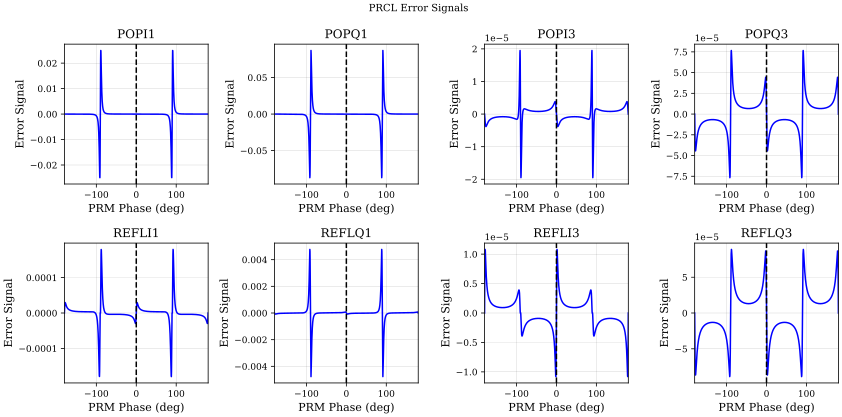

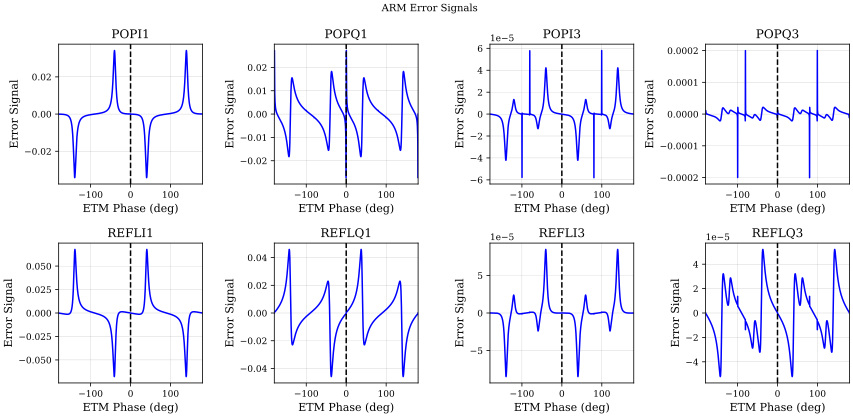

In [33]:
model = build_model()

wide_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 -180,PRM0 + 180, 1000))
wide_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 -180,ETM0 + 180, 1000))

#Plotting the full error signal for PRCL DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_prcl.x[0], wide_prcl[port])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("PRM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("PRCL Error Signals")
plt.tight_layout()
plt.show()

#Plotting the full error signal for ARM DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_arm.x[0], wide_arm[port])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("ETM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("ARM Error Signals")
plt.tight_layout()
plt.show()


### Note

Using the DC-derived operating point gives a sensing matrix that does not look as expected.

As a check, setting both `PRM.phi = 0°` and `ETM.phi = 0°` gives the expected PRCL/ARM separation.

I am not sure which operating point should be used here, so I have kept both results for comparison.